[二分搜索](./basic_algorithm/binary_search.md)  
[排序算法](./basic_algorithm/sort.md)  

### 二分搜索
二分查找（binary search）是一种基于分治策略的高效搜索算法。它利用数据的有序性，每轮缩小一半搜索范围，直至找到目标元素或搜索区间为空为止。也叫二分查找，时间复杂度O(log n)


#### 二分查找的三个模版(优先选用模版3)
你在网上看到的 99% 的二分查找问题会归结于这 3 个模板中的一个。有些问题可以使用多个模板来实现，但是当你做更多的练习时，你会注意到一些模板比其他模板更适合某些问题。

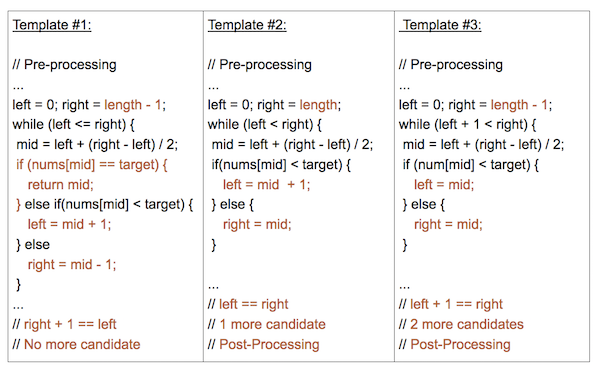


图中标注了left 和 right 位置的关系  
模板 #1 和 #3 是最常用的，几乎所有二分查找问题都可以用其中之一轻松实现。模板 #2 更 高级一些，用于解决某些类型的问题。

三个模板在那种情况下使用？
- 模板1：循环结束后，left 跑到了 right 的右边，很奇怪的现象, 且left -1 = right。right多退了一步  
- 模板2：循环结束后，left = right, 所以只需要一个与目标值比较就好了  
- 模板3：循环结束后，left < right, 且left +1 = right。这是循环条件决定的  


模版详细分析：https://leetcode.cn/leetbook/read/binary-search/xewjg7/


In [ ]:
from typing import List
#  模版python 代码
# 模版1
class Solution:
    def search(self, nums: List[int], target: int) -> int:
        left, right = 0, len(nums) - 1
        while left <= right:
            mid = left + (right - left) // 2
            if nums[mid] == target:
                return mid
            elif nums[mid] < target:
                left = mid + 1 
            else:
                right = mid - 1
        return -1
    
# 模版2
class Solution:
    def search(self, nums: List[int], target: int) -> int:
        left, right = 0, len(nums)-1
        while left < right:
            mid = left + (right - left) // 2
            if nums[mid] < target:
                left = mid + 1
            else:
                right = mid
        return left if nums[left] == target else -1
    
# 模版3
class Solution:
    def search(self, nums: List[int], target: int) -> int:
        left, right = 0, len(nums)-1
        while left+1 < right:
            mid = left + (right - left) // 2
            if nums[mid] < target:
                left = mid
            else:
                right = mid
        if nums[left] == target:
            return left
        elif nums[right] == target:
            return right
        else:
            return -1

    


### 模版2的坑：
最后判断用的left,不是mid  
得到的left = right 是第一个大于target的值，也是要插入的位置，但是呢，这不如模版1，可以获得  left 是第一个大于 target 的索引，right 是最后一个小于 target 的索引，这个right就有用了。  
变体：模版2搜索失败，left-1  

In [ ]:
def searchRange(nums,target):
    range = [-1,-1]
    left,right = 0,len(nums)-1
    # 找第一个元素的下标
    while left +1 < right:
        mid = left + (right-left) // 2
        if nums[mid] < target:
            left = mid
        else:
            right = mid
    if nums[left] == target:
        range[0] = left
    elif nums[right] == target:
        range[0] = right
    else:
        return range
    
    left,right = 0,len(nums)-1
    # 开始找最后一个元素的下标
    while left +1 < right:
        mid = left + (right-left) // 2
        if nums[mid] <= target:
            left = mid
        else:
            right = mid
    if nums[left] == target:
        range[1] = left
    else:
        range[1] = right
    return range
nums = [5,7,7,8,8,8,8,10]
target = 7

searchRange(nums,target)

O(N) 是1+1+1...+1,N个1  
O(log2N) 是    
O(N) 优于O(log2N)吗？    
理论上，除了 𝑁=1 这种极小规模特例外，O(logN) 永远优于 O(N)。  
O(N) ≈ 100 次常数操作  
O(log₂N) ≈ log₂(100) ≈ 6.64 次  
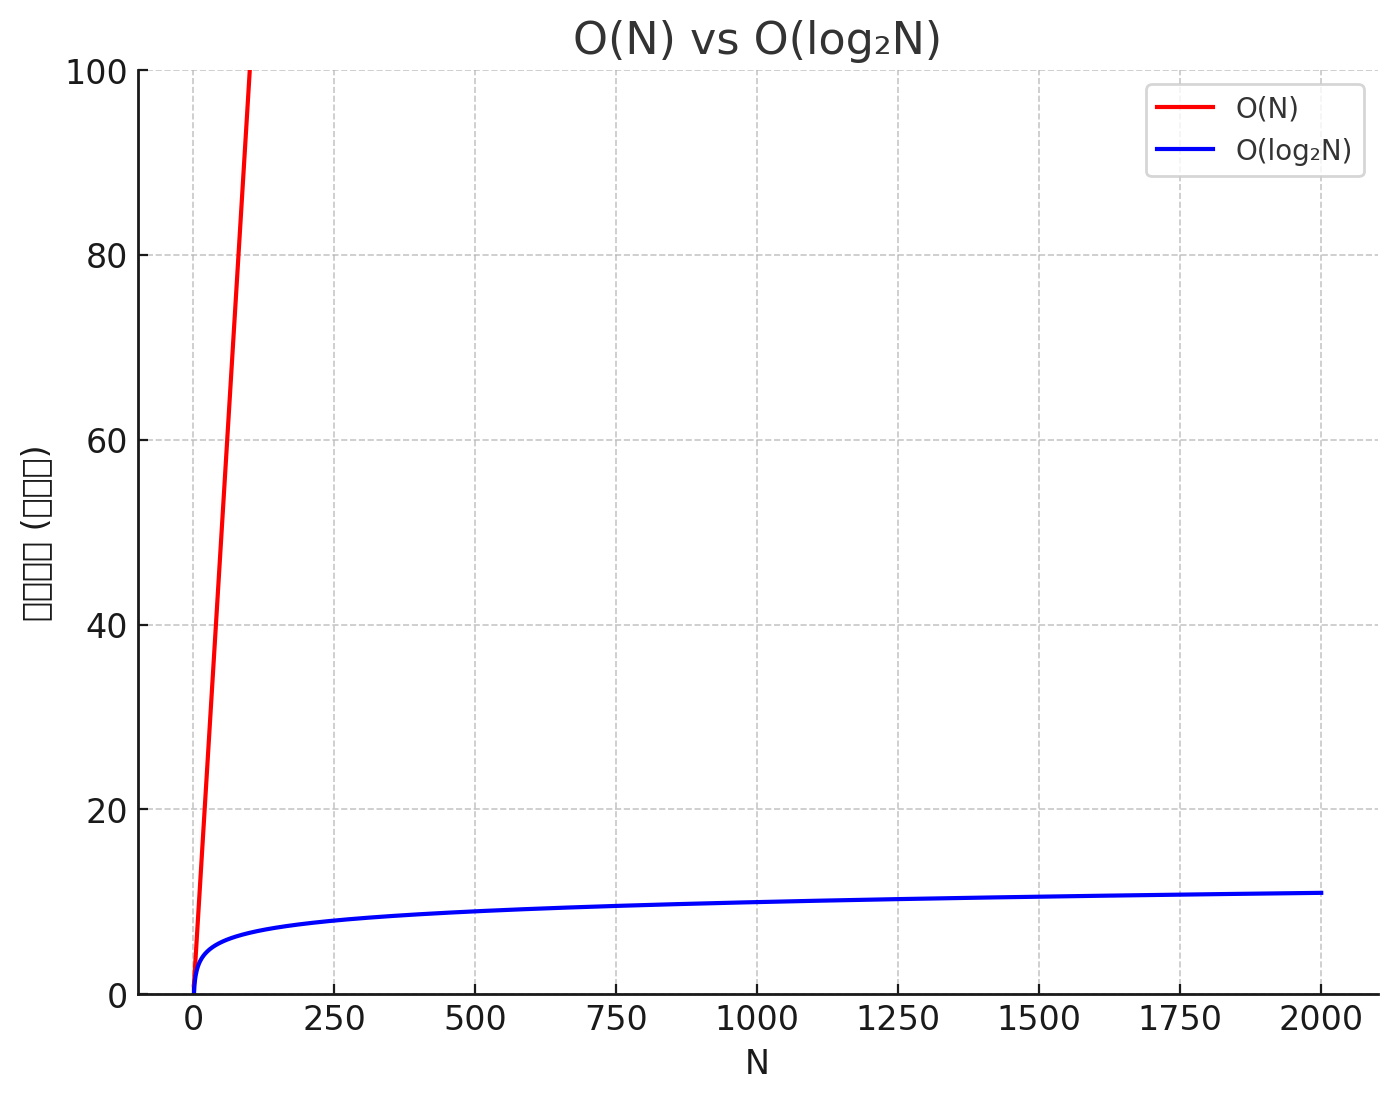


Python 的作用域规则  
Python 中 while 循环、for 循环里的变量不会限制在循环体内部，它们的作用域是整个函数体。  
所以循环结束后，你依然可以访问 row。  

In [15]:
bool(1)

True

In [16]:


def searchMatrix(matrix, target):

    if not len(matrix) or not len(matrix[0]):
        return False
    
    # 不需要找了
    if target > matrix[-1][-1] or target < matrix[0][0]:
        return False
    
    # 定位行数
    l ,r = 0, len(matrix)-1
    while l <= r:
        mid = l + (r-l) // 2
        if matrix[mid][0] == target:
            return True
        elif matrix[mid][0] < target:
            l = mid +1
        else:
             r = mid-1
             
    row = r     

    # 定位列数
    l ,r = 0, len(matrix[row])-1
    while l <= r:
        mid = l + (r-l) // 2
        if matrix[row][mid] == target:
            return True
        elif matrix[row][mid] <  target:
            l = mid + 1
        else:
            r = mid - 1
            
    return False
    
target = 22
matrix = [[1,3,5,7],[10,11,16,20],[23,30,34,60]]
searchMatrix(matrix, target)

False

In [18]:
# 使用二分搜索，当中间元素大于最右侧元素时意味着拐点即最小元素在右侧，否则在左侧
def findMin(nums):
    l,r = 0,len(nums)-1
    while l<r:
        mid = l +(r - l) // 2
        if nums[mid] > nums[r]:
            l = mid+1
        else:
            r = mid
    return nums[l]

In [19]:
def findMin(nums):
    l,r = 0,len(nums)-1
    while l<r:
        mid = l +(r - l) // 2
        if nums[mid] > nums[r]:
            l = mid+1
        elif nums[mid] < nums[r] or nums[mid] != nums[l]:
            r = mid
        else: # nums[l] == nums[mid] == nums[r]
            l += 1
            
    return nums[l]

In [21]:
def search(nums, target):
    pass

In [29]:
# 思路：元素各不相同，可以通过nums[mid] 和 nums[left] 得出左半区有序还是右半区有序

def search(nums, target):
    l,r = 0,len(nums)-1
    while(l <= r):
        mid = l + (r-l) // 2
        if nums[mid] == target:
            return mid
        elif nums[mid] > target:
            # 已经满足条件target 比中间值小
            if nums[l] > target and nums[mid] > nums[l]:
                l = mid +1
            else:
                r = mid - 1
        else: # target 比中间值大 那就看比target大的数的分布
            # 仅仅凭借target > nums[r], 还不能确定落在了左边区间，加上 右区间有序，就可以了
            if nums[r] < target and nums[mid] < nums[l]:
                r = mid -1
            else:
                l = mid +1
    return -1

# nums = [3,4,5,6,7,1,2]
nums = [6,7,1,2,3,4,5]

target = 5
search(nums, target)

6